In [2]:
import tensorflow as tf
from tensorflow import keras 
from keras.layers import  Dense , Flatten 
from keras.models import Sequential 
from keras.applications.vgg16 import VGG16

In [3]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
conv_base = VGG16(include_top= False, input_shape= (150, 150,  3))

In [5]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [6]:
model = Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,  activation= 'relu'))
model.add(Dense(1,  activation= 'sigmoid'))

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 256)               2097408   
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 16,812,353
Non-trainable params: 0
_________________________________________________________________


In [8]:
conv_base.trainable = False 

In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 256)               2097408   
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 2,097,665
Non-trainable params: 14,714,688
_________________________________________________________________


## Method-1 : Feature Extraction

In [10]:
# Using generators => Generator helps to load mini batch data into ram instead of all data directly.
train_ds = keras.utils.image_dataset_from_directory(
    directory=r'C:\Users\Acer\OneDrive\Desktop\DeepLearning\train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory=r'C:\Users\Acer\OneDrive\Desktop\DeepLearning\test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150)
)

Found 19992 files belonging to 2 classes.
Found 4999 files belonging to 2 classes.


In [11]:
def process(image , label):
    image = tf.cast(image/255 , tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds= validation_ds.map(process)

In [12]:
model.compile(loss= 'binary_crossentropy' , optimizer= 'adam' , metrics= ['accuracy'])

In [13]:
history = model.fit(train_ds , epochs= 10 , validation_data= validation_ds)

Epoch 1/10
625/625 [==============================] - 65s 85ms/step - loss: 0.2770 - accuracy: 0.8836 - val_loss: 0.2077 - val_accuracy: 0.9164
Epoch 2/10
625/625 [==============================] - 49s 78ms/step - loss: 0.1906 - accuracy: 0.9212 - val_loss: 0.2050 - val_accuracy: 0.9166
Epoch 3/10
625/625 [==============================] - 49s 78ms/step - loss: 0.1609 - accuracy: 0.9334 - val_loss: 0.2451 - val_accuracy: 0.8980
Epoch 4/10
625/625 [==============================] - 49s 79ms/step - loss: 0.1442 - accuracy: 0.9421 - val_loss: 0.2713 - val_accuracy: 0.8920
Epoch 5/10
625/625 [==============================] - 49s 78ms/step - loss: 0.1254 - accuracy: 0.9489 - val_loss: 0.2236 - val_accuracy: 0.9144
Epoch 6/10
625/625 [==============================] - 49s 78ms/step - loss: 0.1065 - accuracy: 0.9564 - val_loss: 0.2591 - val_accuracy: 0.9040
Epoch 7/10
625/625 [==============================] - 49s 78ms/step - loss: 0.0823 - accuracy: 0.9699 - val_loss: 0.2648 - val_accuracy:

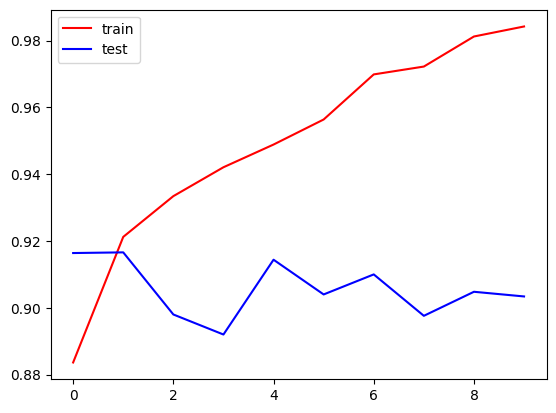

In [17]:
import matplotlib.pyplot as plt 

plt.plot(history.history['accuracy'], color= 'red' , label= 'train')
plt.plot(history.history['val_accuracy'], color= 'blue' , label= 'test')
plt.legend()
plt.show()

## Method-2: Data Augmentation

In [19]:
conv_base.trainable = True 

set_trainable = False 

for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True 

    if set_trainable:
        layer.trainable = True 
    else:
        layer.trainable =False 

for layer in conv_base.layers:
    print(layer.name , layer.trainable)

input_1 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 256)               2097408   
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 9,177,089
Non-trainable params: 7,635,264
_________________________________________________________________


In [21]:
model = Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,  activation='relu'))
model.add(Dense(1,  activation='sigmoid'))

In [22]:
# Using generators => Generator helps to load mini batch data into ram instead of all data directly.
train_ds = keras.utils.image_dataset_from_directory(
    directory=r'C:\Users\Acer\OneDrive\Desktop\DeepLearning\train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory=r'C:\Users\Acer\OneDrive\Desktop\DeepLearning\test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150, 150)
)

Found 19992 files belonging to 2 classes.
Found 4999 files belonging to 2 classes.


In [23]:
def process(image, label):
    image = tf.cast(image/255, tf.float32)
    return image, label


train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [24]:
model.compile(loss='binary_crossentropy',
              optimizer=keras.optimizers.RMSprop(learning_rate= 1e-5), metrics=['accuracy'])

In [25]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 [==============================] - 61s 94ms/step - loss: 0.2363 - accuracy: 0.8995 - val_loss: 0.1599 - val_accuracy: 0.9368
Epoch 2/10
625/625 [==============================] - 58s 92ms/step - loss: 0.1297 - accuracy: 0.9486 - val_loss: 0.1345 - val_accuracy: 0.9452
Epoch 3/10
625/625 [==============================] - 58s 92ms/step - loss: 0.0901 - accuracy: 0.9666 - val_loss: 0.1234 - val_accuracy: 0.9496
Epoch 4/10
625/625 [==============================] - 58s 93ms/step - loss: 0.0614 - accuracy: 0.9788 - val_loss: 0.1270 - val_accuracy: 0.9496
Epoch 5/10
625/625 [==============================] - 58s 93ms/step - loss: 0.0401 - accuracy: 0.9873 - val_loss: 0.1229 - val_accuracy: 0.9548
Epoch 6/10
625/625 [==============================] - 58s 93ms/step - loss: 0.0254 - accuracy: 0.9935 - val_loss: 0.1386 - val_accuracy: 0.9532
Epoch 7/10
625/625 [==============================] - 58s 93ms/step - loss: 0.0155 - accuracy: 0.9965 - val_loss: 0.1462 - val_accuracy: